• Minggu 1-2 (Inisiasi):

In [1]:
pip install google-play-scraper

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd

# Ambil review Gojek
result, _ = reviews(
    'com.gojek.app',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

# Convert ke DataFrame
df = pd.DataFrame(result)

# Ambil kolom penting
df = df[['content', 'score']]

# Rename
df.columns = ['text', 'rating']

# Simpan RAW DATA
df.to_csv("data_raw_gojek.csv", index=False)

print(df.head())
print("Jumlah data:", len(df))

                                                text  rating
0                                oke sangat membantu       5
1                                           goodluck       5
2  Saya menyaygkan keputusan sepihak terkait peng...       1
3                             praktis di saat kritis       5
4                                               asik       5
Jumlah data: 2000


In [3]:
import os

# buat folder data/raw
os.makedirs("data/raw", exist_ok=True)

print("Folder berhasil dibuat!")

Folder berhasil dibuat!


In [4]:
df.to_csv("data/raw/data_raw_gojek.csv", index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


In [5]:
from google.colab import files

files.download("data/raw/data_raw_gojek.csv")

ModuleNotFoundError: No module named 'google.colab'

• Minggu 3-4 (Data Profiling)

In [6]:
print(df.isnull().sum())

text      0
rating    0
dtype: int64


In [7]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 386


In [8]:
df['length'] = df['text'].astype(str).apply(len)

print(df['length'].describe())

count    2000.000000
mean       65.025000
std        92.231159
min         1.000000
25%         9.000000
50%        27.000000
75%        79.250000
max       500.000000
Name: length, dtype: float64


In [9]:
df.sample(10)

,text,rating,length
971,pantauannya akurat,5,18
1686,pesan gocar comfort tarif 31. pas charge jadi ...,3,182
1844,aplikasi sejuta ummat yg sangat bermanfaat,5,42
1612,susah cari driver,2,17
158,4 karna gocat,4,13
1470,susah download lambat,2,21
123,intinya saling menguntungkan👏,5,29
875,baik,3,4
258,"Ramah, Cepat, Percaya",5,21
1872,okelah,5,6


In [10]:
from collections import Counter

all_text = " ".join(df['text'].astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)

print(word_counts.most_common(20))

[('di', 383), ('driver', 362), ('dan', 315), ('saya', 298), ('gojek', 238), ('sangat', 231), ('aplikasi', 218), ('yg', 207), ('nya', 193), ('tidak', 190), ('yang', 185), ('ga', 168), ('bisa', 163), ('bagus', 159), ('ada', 158), ('gak', 153), ('mau', 148), ('membantu', 133), ('ini', 131), ('tapi', 113)]

In [11]:
!pip install wordcloud matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


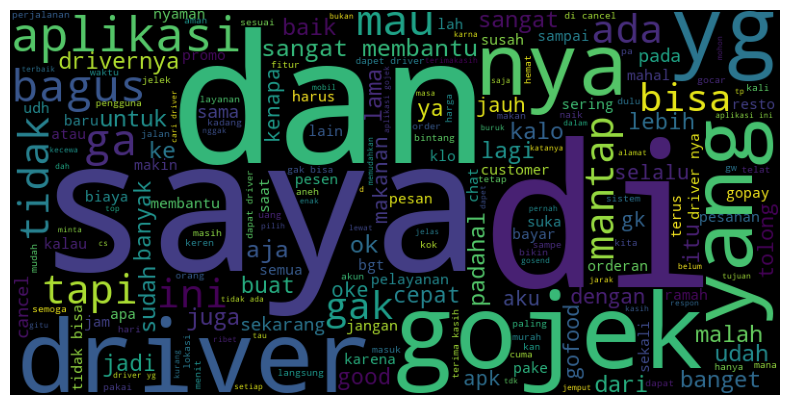

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

• Minggu 5-6 (Basic Cleaning):

In [13]:
#CASE FOLDING
df['text'] = df['text'].astype(str).str.lower()

In [14]:
#REGEX CLEANING
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)       # hapus URL
    text = re.sub(r'@\w+', '', text)          # hapus mention
    text = re.sub(r'#\w+', '', text)          # hapus hashtag
    text = re.sub(r'\d+', '', text)           # hapus angka
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # hapus simbol & emoji
    text = re.sub(r'\s+', ' ', text).strip()  # hapus spasi berlebih
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [15]:
#FILTERING
# hapus teks yang terlalu pendek (< 3 kata)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df_filtered = df[df['word_count'] >= 3]

print("Sebelum filtering:", len(df))
print("Sesudah filtering:", len(df_filtered))

Sebelum filtering: 2000
Sesudah filtering: 1236


In [16]:
import os

os.makedirs("data/processed", exist_ok=True)

df_filtered.to_csv("data/processed/data_clean_gojek.csv", index=False)

• Minggu 7-8 (Advanced Normalization)

In [17]:
import pandas as pd

df = pd.read_csv("data/processed/data_clean_gojek.csv")
df.head()

,text,rating,length,clean_text,word_count
0,oke sangat membantu,5,19,oke sangat membantu,3
1,saya menyaygkan keputusan sepihak terkait peng...,1,500,saya menyaygkan keputusan sepihak terkait peng...,69
2,praktis di saat kritis,5,22,praktis di saat kritis,4
3,driver sangat berhati2 dalam membawa penumpang...,5,114,driver sangat berhati dalam membawa penumpangt...,14
4,sangat membantu dlm perjalanan,5,30,sangat membantu dlm perjalanan,4


In [18]:
slang_dict = {
    "bgt": "banget",
    "bgtt": "banget",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "mantul": "mantap betul",
    "oke": "baik",
    "ok": "baik",
    "dr": "dari",
    "tp": "tapi",
    "aja": "saja",
    "udh": "sudah",
    "blm": "belum",
    "lg": "lagi",
    "krn": "karena",
    "dgn": "dengan"
}

In [19]:
#NORMALISASI TEKS
def normalize_text(text):
    words = text.split()
    normalized = [slang_dict[word] if word in slang_dict else word for word in words]
    return " ".join(normalized)

df['normalized_text'] = df['clean_text'].apply(normalize_text)

In [20]:
df[['clean_text', 'normalized_text']].head(10)

,clean_text,normalized_text
0,oke sangat membantu,baik sangat membantu
1,saya menyaygkan keputusan sepihak terkait peng...,saya menyaygkan keputusan sepihak terkait peng...
2,praktis di saat kritis,praktis di saat kritis
3,driver sangat berhati dalam membawa penumpangt...,driver sangat berhati dalam membawa penumpangt...
4,sangat membantu dlm perjalanan,sangat membantu dlm perjalanan
5,bintang aja dulu ruwet kek co nya gk jelas,bintang saja dulu ruwet kek co nya tidak jelas
6,bagaimana ya dengan aplikasi ini apakah tidak ...,bagaimana ya dengan aplikasi ini apakah tidak ...
7,gajelas banget posisi dirumah tapi di maps lok...,gajelas banget posisi dirumah tapi di maps lok...
8,semuanya sebenarnya nyaman aja maaf kalo dilua...,semuanya sebenarnya nyaman saja maaf kalo dilu...
9,gojek layanan nya lengkap,gojek layanan nya lengkap


In [21]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
#TOKENIZING
from nltk.tokenize import word_tokenize

df['tokens'] = df['normalized_text'].apply(word_tokenize)

In [23]:
!pip install google-play-scraper Sastrawi nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
#STOPWORD REMOVAL
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stopwords])

In [25]:
#STEMPING
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

df['tokens'] = df['tokens'].apply(lambda x: [stemmer.stem(word) for word in x])

In [26]:
df['final_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [27]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/data_final_gojek.csv", index=False)

print("Advanced normalization selesai!")

Advanced normalization selesai!


In [28]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [29]:
df.to_csv('/content/drive/MyDrive/data_final_gojek.csv', index=False)

OSError: Cannot save file into a non-existent directory: '\content\drive\MyDrive'

In [30]:
df[['text', 'final_text']].sample(10)

,text,final_text
375,"pengiriman cepat, tepat waktu, banyak diskonny...",kirim cepat tepat waktu banyak diskon sukses s...
688,apk bagus terbaik,apk bagus baik
1007,aplikasi ga jelas tolol,aplikasi jelas tolol
1023,instal dari 2018 sampai skrng ga kebuka spinja...,instal skrng buka spinjam aneh banget padahal ...
662,untuk developer tolong perbaiki aplikasi nya p...,developer baik aplikasi nya padahal sinyal ku ...
44,gojek sangat membantu saya untuk aktivitas har...,gojek sangat bantu aktivitas hari antar jemput...
356,aplikasi terpercaya untuk pengguna yang cepat ...,aplikasi percaya guna cepat tanggap respon
301,alhamdulillah saya puas dengan layanan gojek y🙏,alhamdulillah puas layan gojek y
974,aplikasi lawak padahal pengguna lama tapi ngaj...,aplikasi lawak padahal guna lama ngajuin gopay...
529,gw si yes,gw si yes


In [31]:
df[['text', 'clean_text', 'normalized_text', 'final_text']].sample(10)

,text,clean_text,normalized_text,final_text
429,aplikasi bgnian aplikasi monyet... gua pesan m...,aplikasi bgnian aplikasi monyet gua pesan mart...,aplikasi bgnian aplikasi monyet gua pesan mart...,aplikasi bgnian aplikasi monyet gua pesan mart...
197,banyak promo..gojek indonesia sukses selalu,banyak promogojek indonesia sukses selalu,banyak promogojek indonesia sukses selalu,banyak promogojek indonesia sukses selalu
734,sesuai dg kebutuhan yg tergesa gesa,sesuai dg kebutuhan yg tergesa gesa,sesuai dg kebutuhan yg tergesa gesa,sesuai dg butuh yg gesa gesa
664,sangat membantu perjalanan ku pulang pergi,sangat membantu perjalanan ku pulang pergi,sangat membantu perjalanan ku pulang pergi,sangat bantu jalan ku pulang pergi
1092,"tidak pernah ganti hp, tapi kalo isi gopay sel...",tidak pernah ganti hp tapi kalo isi gopay sela...,tidak pernah ganti hp tapi kalo isi gopay sela...,pernah ganti hp kalo isi gopay selalu minta ve...
488,moda transportasi yang nyaman dan terbaikku,moda transportasi yang nyaman dan terbaikku,moda transportasi yang nyaman dan terbaikku,moda transportasi nyaman baik
591,so far so good,so far so good,so far so good,so far so good
624,salah satu aplikasi favorit ku yang bisa memba...,salah satu aplikasi favorit ku yang bisa memba...,salah satu aplikasi favorit ku yang bisa memba...,salah satu aplikasi favorit ku bantu mudah seg...
439,kacau gak bisa nlp,kacau gak bisa nlp,kacau gak bisa nlp,kacau gak nlp
608,bagus dan membantu,bagus dan membantu,bagus dan membantu,bagus bantu


In [32]:
df[['text', 'final_text']].sample(5)

,text,final_text
1203,cukup membantu dan memudahkan untuk q yg mageran🙏,cukup bantu mudah q yg mageran
820,masa pesen gocar titik nya suruh edit katanya ...,masa sen gocar titik nya suruh edit kata ter a...
144,dengan adanya aplikasi ini semuanya jadi mudah,ada aplikasi semua jadi mudah
544,aku suka apk gojek selagi membutuhkan sangat c...,aku suka apk gojek butuh sangat cepat aku perc...
886,sekarang banyak banget driver ngubah harga see...,sekarang banyak banget driver ngubah harga ena...


• Minggu 9-10 (Domain-Specific Labeling)

In [33]:
#LABELING
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['label'] = df['rating'].apply(label_sentiment)

df[['rating', 'label']].head()

,rating,label
0,5,positif
1,1,negatif
2,5,positif
3,5,positif
4,5,positif


In [34]:
df['label'].value_counts()

label
positif    655
negatif    521
netral      60
Name: count, dtype: int64

In [35]:
(df['label'].value_counts(normalize=True) * 100).round(2)

label
positif    52.99
negatif    42.15
netral      4.85
Name: proportion, dtype: float64

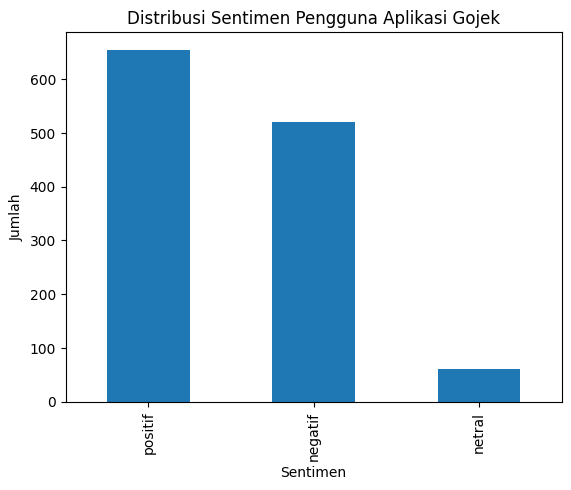

In [36]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen Pengguna Aplikasi Gojek")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

In [37]:
df.groupby('label')['rating'].mean()

label
negatif    1.122841
netral     3.000000
positif    4.891603
Name: rating, dtype: float64

In [38]:
df['label'].value_counts()

label
positif    655
negatif    521
netral      60
Name: count, dtype: int64

• Minggu 11-12 (Validation & Documentation)

In [39]:
df_sample = df.sample(100)
df_sample[['text', 'final_text']].head(10)

,text,final_text
1197,kenapa nomor saya tiap daftar gopayletter sela...,nomor tiap daftar gopayletter selalu tolak
1110,tilok dan alamat dibogor tiba2 kegeser dan ber...,tilok alamat bogor tiba geser ubah jadi tilok ...
757,"ga bisa order, gabisa login aneh",order gabisa login aneh
1219,sangat di butuhkan ketika pingin jajan atau ma...,sangat butuh pingin jajan makan yg sangat enak
1118,aplikasi andalan kalo daruratt mantepp pooll,aplikasi andal kalo daruratt mantepp pooll
955,"driver lu pada males, apalagi bandung",driver lu males bandung
1033,sudah bagus tapi baiknya untuk gobox juga bisa...,bagus baik gobox dishare tracking jalan gosend...
1156,ajarin drivermu tentang adab dan akhlak,ajarin drivermu adab akhlak
348,pasti terlaksana apapun kebutuhan kita di wakt...,laksana apa butuh waktu pakai aplikasi
641,"apaan pesen gofood udh 1 jam blm dapet driver,...",apa sen gofood jam dapet driver suru batalin y...


In [40]:
df.groupby('label')['rating'].mean()

label
negatif    1.122841
netral     3.000000
positif    4.891603
Name: rating, dtype: float64

In [41]:
df.sample(10)[['text','final_text']]

,text,final_text
25,saya sangat bersyukur dengan adanya aplikasi g...,sangat syukur ada aplikasi gojek semua simple ...
768,berguna untuk rakyat yang tidak punya motor,guna rakyat punya motor
423,driver nya selalu ramah tamah.. namun untuk me...,driver nya selalu ramah tamah laku booking gor...
883,"bukan apps nya yang bermasalah,melainkan deive...",bukan apps nya bermasalahmelainkan deivernya g...
992,"sopirnya baik sopan senang bercanda ,,,,good j...",sopir baik sopan senang canda good job
803,mantap aman bagus,mantap aman bagus
702,nadim makarim pencipta 32 juta lapangan pekerjaan,nadim makarim cipta juta lapang kerja
214,diwilayah saya susah cari drivernya,wilayah susah cari drivernya
817,"aplikasi tolol, gagal terus mau masuk verifika...",aplikasi tolol gagal terus mau masuk verifikas...
340,lebih detail dripada apk sebelah,lebih detail dripada apk belah


• MODELING + EVALUASI (LOGISTIC REGRESSION)

In [42]:
import pandas as pd

df = pd.read_csv("data/processed/data_final_gojek.csv")

df.head()

,text,rating,length,clean_text,word_count,normalized_text,tokens,final_text
0,oke sangat membantu,5,19,oke sangat membantu,3,baik sangat membantu,"['baik', 'sangat', 'bantu']",baik sangat bantu
1,saya menyaygkan keputusan sepihak terkait peng...,1,500,saya menyaygkan keputusan sepihak terkait peng...,69,saya menyaygkan keputusan sepihak terkait peng...,"['menyaygkan', 'putus', 'pihak', 'kait', 'hapu...",menyaygkan putus pihak kait hapus voucher prom...
2,praktis di saat kritis,5,22,praktis di saat kritis,4,praktis di saat kritis,"['praktis', 'kritis']",praktis kritis
3,driver sangat berhati2 dalam membawa penumpang...,5,114,driver sangat berhati dalam membawa penumpangt...,14,driver sangat berhati dalam membawa penumpangt...,"['driver', 'sangat', 'hati', 'bawa', 'penumpan...",driver sangat hati bawa penumpangtidak ugal an...
4,sangat membantu dlm perjalanan,5,30,sangat membantu dlm perjalanan,4,sangat membantu dlm perjalanan,"['sangat', 'bantu', 'dlm', 'jalan']",sangat bantu dlm jalan


In [43]:
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['label'] = df['rating'].apply(label_sentiment)

In [44]:
df['label'].value_counts()

label
positif    655
negatif    521
netral      60
Name: count, dtype: int64

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['final_text']
y = df['label']

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

NameError: name 'X_tfidf' is not defined

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')

model.fit(X_train, y_train)

print("Training selesai!")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [48]:
y_pred = model.predict(X_test)

print(y_pred[:10])

NameError: name 'model' is not defined

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

NameError: name 'y_test' is not defined

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

NameError: name 'y_test' is not defined

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

NameError: name 'y_test' is not defined

### ANALISIS TAMBAHAN LOGISTIC REGRESSION

In [52]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# Encode label untuk ROC curve (one-vs-rest)
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_proba = model.predict_proba(X_test)

# Hitung ROC AUC untuk setiap kelas
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='weighted')
print(f"Weighted ROC AUC Score: {roc_auc:.4f}")

NameError: name 'y_test' is not defined

NameError: name 'model' is not defined

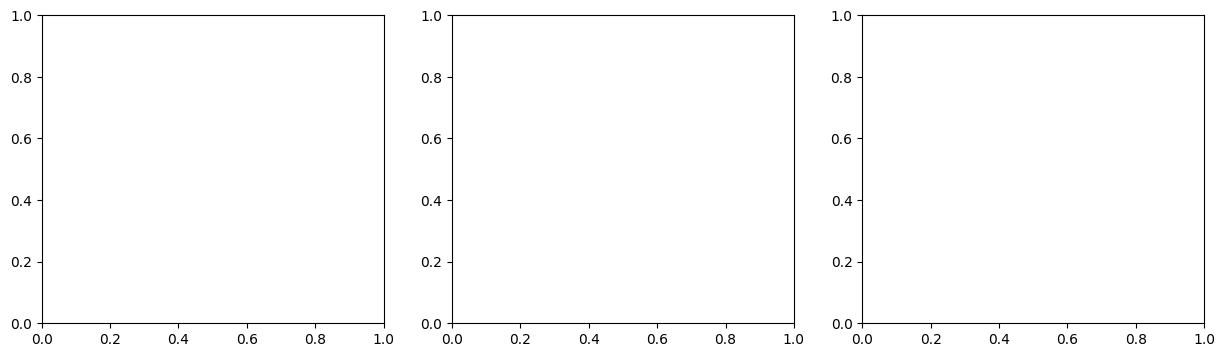

In [53]:
# Visualisasi probabilitas prediksi
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_names = model.classes_
for i, class_name in enumerate(class_names):
    axes[i].hist(y_pred_proba[:, i], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribusi Probabilitas Kelas: {class_name}')
    axes[i].set_xlabel('Probabilitas')
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [54]:
# Feature importance (koefisien model)
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_

# Ambil top features untuk setiap kelas
for i, class_name in enumerate(model.classes_):
    top_indices = np.argsort(np.abs(coefficients[i]))[-10:]
    top_features = feature_names[top_indices]
    top_coef = coefficients[i][top_indices]
    
    print(f"\nTop 10 Features untuk kelas '{class_name}':")
    for feat, coef in zip(top_features, top_coef):
        print(f"  {feat}: {coef:.4f}")

NotFittedError: Vocabulary not fitted or provided

In [55]:
# Test dengan contoh teks baru
test_texts = [
    "aplikasi sangat membantu dan mudah digunakan",
    "aplikasi ini jelek dan sering error",
    "biasa saja tidak buruk tidak bagus"
]

test_tfidf = tfidf.transform(test_texts)
predictions = model.predict(test_tfidf)
probabilities = model.predict_proba(test_tfidf)

print("\nPrediksi Sentimen Teks Baru:")
print("="*70)

for text, pred, probs in zip(test_texts, predictions, probabilities):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}")
    print(f"Confidence:")
    for class_name, prob in zip(model.classes_, probs):
        print(f"  {class_name}: {prob:.4f}")
    print("-"*70)

NotFittedError: Vocabulary not fitted or provided